In [498]:
import sys 
sys.path.append(r"C:\Users\baptiste.menetrier\Desktop\devPy\phd")

from propa.rtf.rtf_localisation.zhang_et_al_testcase.zhang_misc import (
    get_estimated_src_pos,
    get_axis_order,
)



import xarray as xr 
import numpy as np
import matplotlib.pyplot as plt 
from skimage.segmentation import clear_border
from skimage import measure
from skimage.measure import label, regionprops
from scipy import ndimage as ndi
from scipy.ndimage import measurements, center_of_mass, binary_dilation, zoom, label
from sklearn.cluster import KMeans
from itertools import combinations
from skimage.filters import sobel
from scipy.spatial import ConvexHull
from scipy.ndimage import gaussian_filter
from sklearn import preprocessing

import matplotlib.pyplot as plt

from skimage.morphology import disk
from skimage.segmentation import watershed
from skimage import data
from skimage.filters import rank
from skimage.util import img_as_ubyte

In [499]:
# Load data
# # Reduced dataset (debug mode)
# fpath = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\propa\rtf\rtf_localisation\zhang_et_al_testcase\data\from_signal_dx20m_dy20m\snr_0.0dB\loc_zhang_dx20m_dy20m_snr0.0dB_mc1_fullarray_s1_s2_s3_s4_s5_s6.nc"
# Full dataset (cas favorable snr 0 et antenne complète)
# fpath = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\propa\rtf\rtf_localisation\zhang_et_al_testcase\data\backups\rtf_zhang_backup_26032025\data\from_signal_dx20m_dy20m\snr_0.0dB\loc_zhang_dx20m_dy20m_snr0.0dB_mc120_fullarray_s1_s2_s3_s4_s5_s6.nc"

# - 10dB
# fpath = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\propa\rtf\rtf_localisation\zhang_et_al_testcase\data\backups\rtf_zhang_backup_16032025_1600\data\from_signal_dx20m_dy20m\snr_-10.0dB\loc_zhang_dx20m_dy20m_snr-10dB_mc0_fullarray_s1_s2_s3_s4_s5_s6.nc"

# -5dB
# fpath = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\propa\rtf\rtf_localisation\zhang_et_al_testcase\data\backups\rtf_zhang_backup_16032025_1600\data\from_signal_dx20m_dy20m\snr_-5.0dB\loc_zhang_dx20m_dy20m_snr-5dB_mc0_fullarray_s1_s2_s3_s4_s5_s6.nc"

# 10 dB
fpath = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\propa\rtf\rtf_localisation\zhang_et_al_testcase\data\backups\rtf_zhang_backup_16032025_1600\data\from_signal_dx20m_dy20m\snr_10.0dB\loc_zhang_dx20m_dy20m_snr10dB_mc0_fullarray_s1_s2_s3_s4_s5_s6.nc"
ds = xr.open_dataset(fpath)

In [500]:
ds

<xarray.Dataset> Size: 63kB
Dimensions:    (y: 51, x: 51)
Coordinates:
  * x          (x) float64 408B 3.5e+03 3.52e+03 3.54e+03 ... 4.48e+03 4.5e+03
  * y          (y) float64 408B 6.4e+03 6.42e+03 6.44e+03 ... 7.38e+03 7.4e+03
Data variables:
    theta_rtf  (y, x) float64 21kB ...
    d_rtf      (y, x) float64 21kB ...
    d_gcc      (y, x) float64 21kB ...
Attributes:
    idx_rcv:  [0 1 2 3 4 5]
    snr:      10

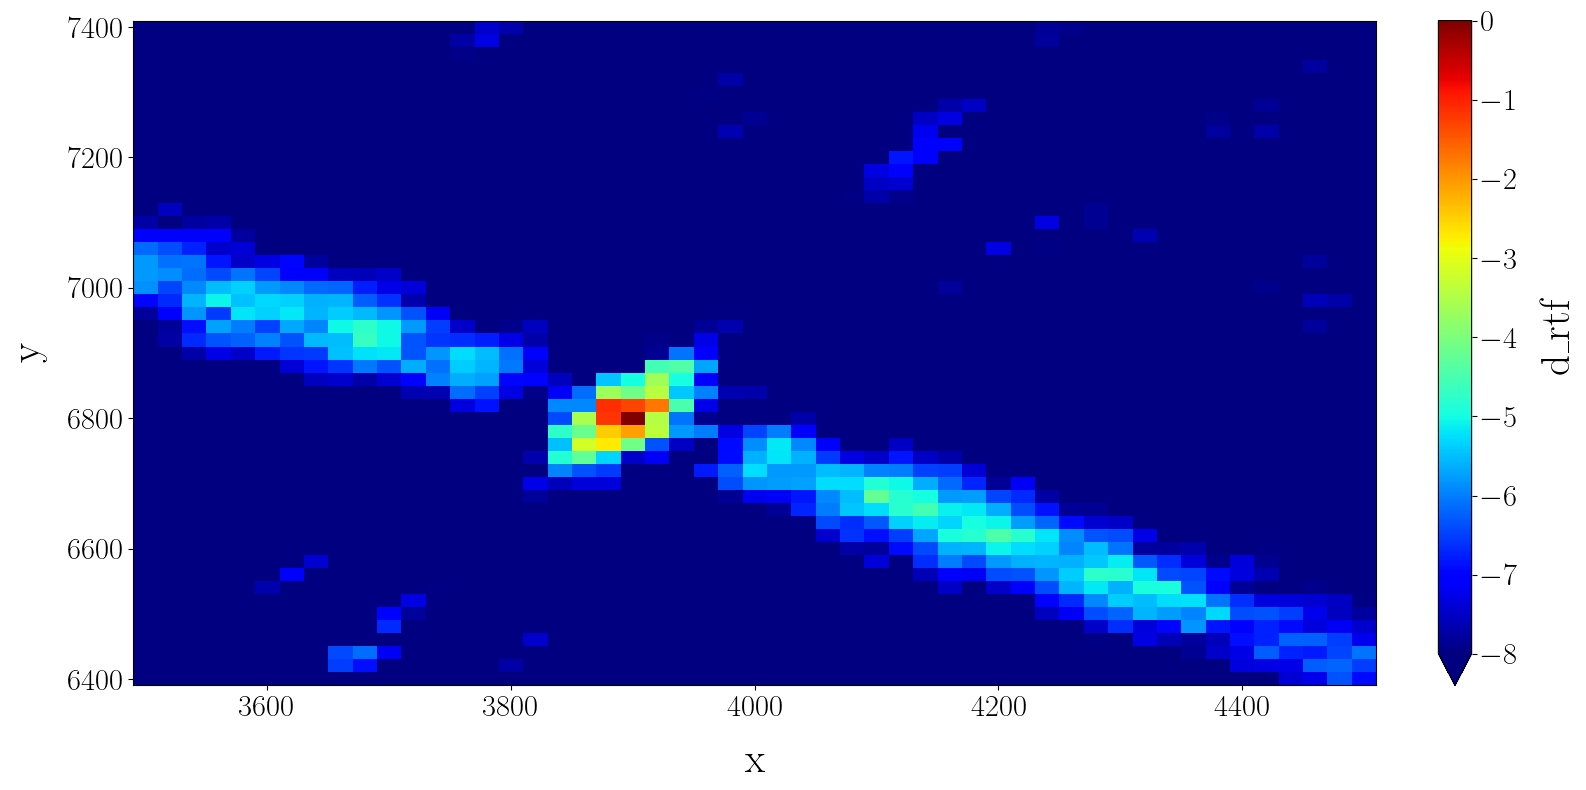

In [501]:
ds.d_rtf.plot(x="x", cmap="jet", vmin=-8)

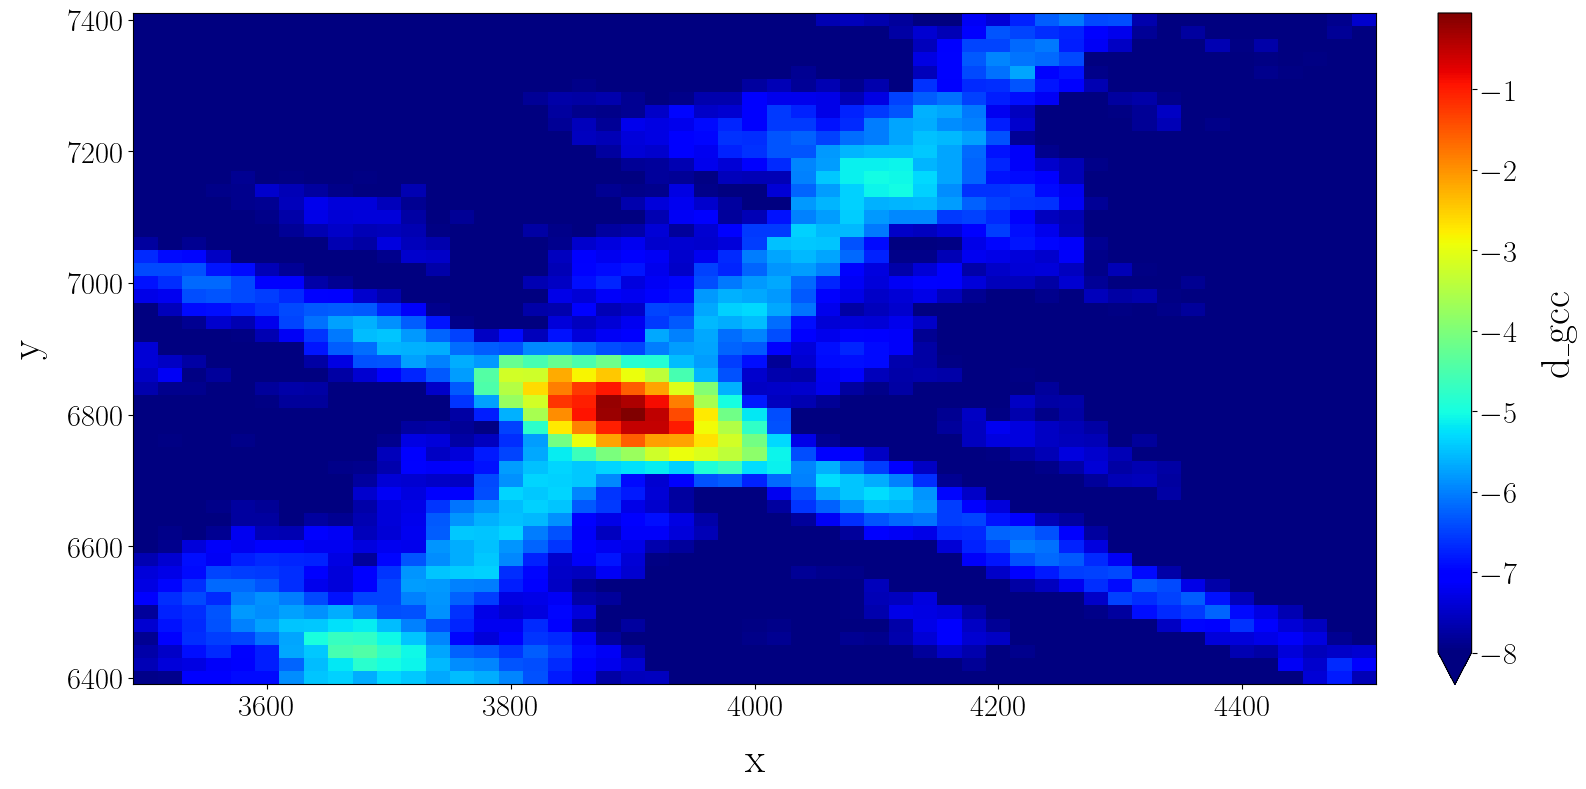

In [549]:
ds.d_gcc.plot(x="x", cmap="jet", vmin=-8)

In [503]:
image_dcf = 10 ** (ds.d_gcc.values / 10)
image_dcf = img_as_ubyte(image_dcf)

image_rtf = 10 ** (ds.d_rtf.values / 10)
image_rtf = img_as_ubyte(image_rtf)

# Première approche : k-means

In [504]:
def apply_kmeans(X, n_clusters):
    # Normalize features
    X_norm = preprocessing.normalize(X).T
    # Apply kmeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init="auto")
    kmeans.fit(X_norm)

    # Get labels
    labels = kmeans.labels_

    return labels

## Features : intensité 

In [505]:
n_clusters = 7
# Kmeans avec seulement les intensités des pixels
X_dcf = image_dcf.flatten()[np.newaxis, :]
X_rtf = image_rtf.flatten()[np.newaxis, :]

In [506]:
X_rtf.shape

(1, 2601)

In [507]:
labels_dcf = apply_kmeans(X_dcf, n_clusters)
labels_rtf = apply_kmeans(X_rtf, n_clusters)

In [508]:
# Reshape labels to 2d arrays 
labels_dcf = labels_dcf.reshape(ds.d_gcc.shape)
labels_rtf = labels_rtf.reshape(ds.d_rtf.shape)

In [509]:
labels_dcf.shape

(51, 51)

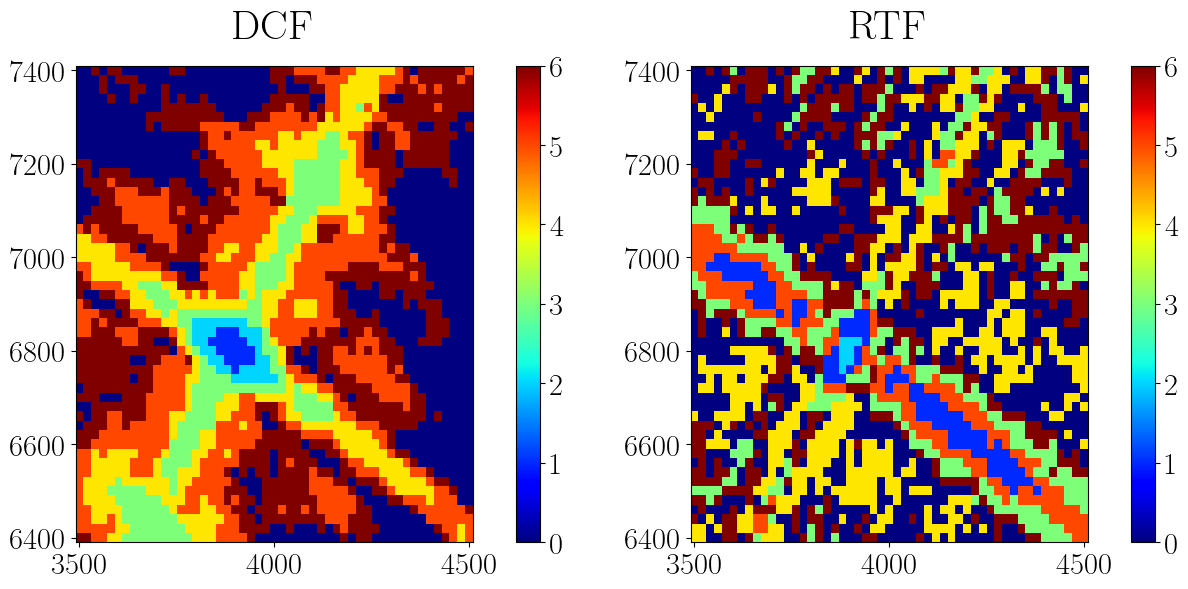

In [510]:
# Plot labels
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
im0 = axs[0].pcolormesh(ds.x, ds.y, labels_dcf, cmap="jet")
plt.colorbar(im0, ax=axs[0])
axs[0].set_title("DCF")

im1 = axs[1].pcolormesh(ds.x, ds.y, labels_rtf, cmap="jet")
axs[1].set_title("RTF")
plt.colorbar(im1, ax=axs[1])

## Feature : intensité avec pré-traitement 

In [511]:
disk_size = 4
image_dcf_smooth = rank.median(image_dcf, disk(disk_size))
image_rtf_smooth = rank.median(image_rtf, disk(disk_size))

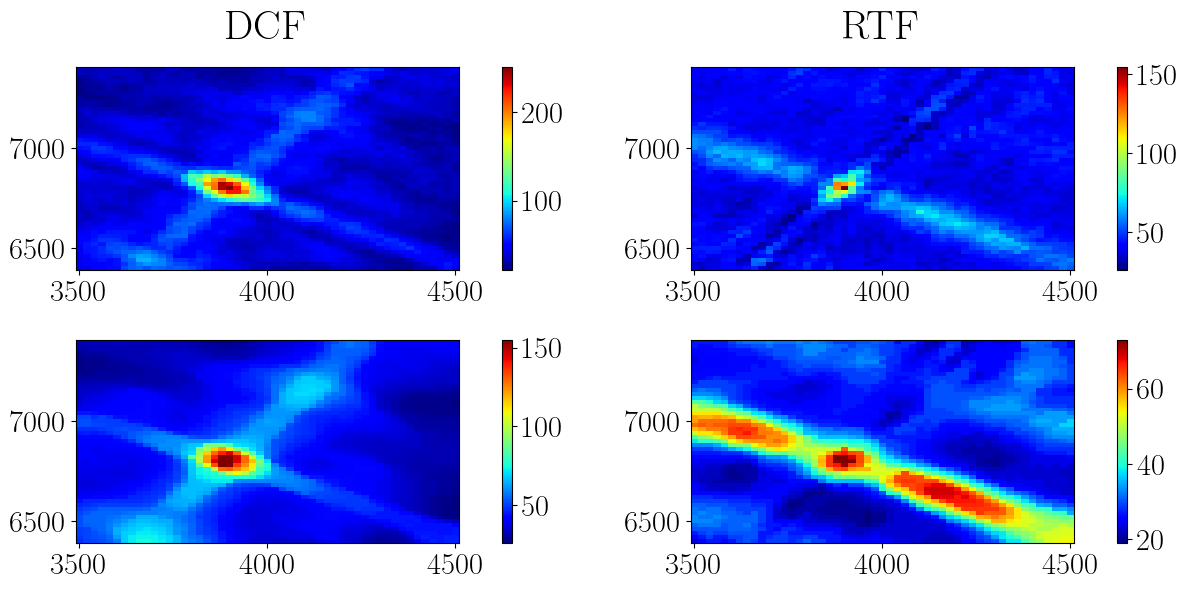

In [512]:
# Plot smoothed images
fig, axs = plt.subplots(2, 2, figsize=(12, 6))
im0 = axs[0, 0].pcolormesh(ds.x, ds.y, image_dcf, cmap="jet")
plt.colorbar(im0, ax=axs[0, 0])
im0 = axs[1, 0].pcolormesh(ds.x, ds.y, image_dcf_smooth, cmap="jet")
plt.colorbar(im0, ax=axs[1, 0])
axs[0, 0].set_title("DCF")

im1 = axs[0, 1].pcolormesh(ds.x, ds.y, image_rtf, cmap="jet")
plt.colorbar(im0, ax=axs[0, 1])
im1 = axs[1, 1].pcolormesh(ds.x, ds.y, image_rtf_smooth, cmap="jet")
axs[0, 1].set_title("RTF")
plt.colorbar(im1, ax=axs[1, 1])

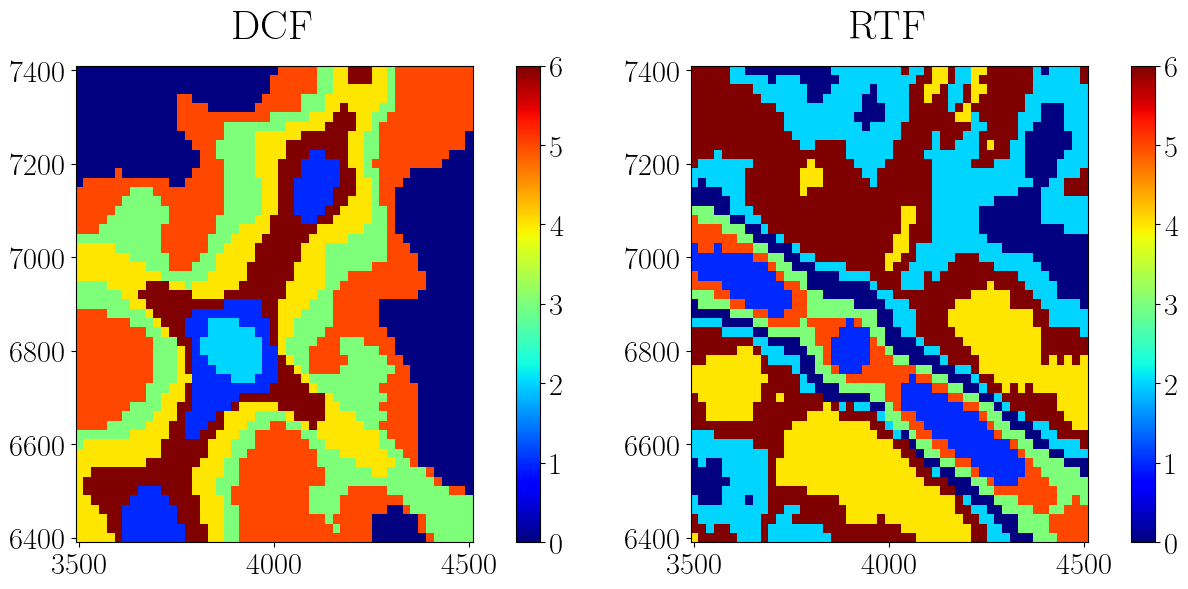

In [513]:
n_clusters = 7
# Kmeans avec seulement les intensités des pixels
X_dcf = image_dcf_smooth.flatten()[np.newaxis, :]
X_rtf = image_rtf_smooth.flatten()[np.newaxis, :]
labels_dcf = apply_kmeans(X_dcf, n_clusters)
labels_rtf = apply_kmeans(X_rtf, n_clusters)
# Reshape labels to 2d arrays
labels_dcf = labels_dcf.reshape(ds.d_gcc.shape)
labels_rtf = labels_rtf.reshape(ds.d_rtf.shape)
# Plot labels
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
im0 = axs[0].pcolormesh(ds.x, ds.y, labels_dcf, cmap="jet")
plt.colorbar(im0, ax=axs[0])
axs[0].set_title("DCF")
im1 = axs[1].pcolormesh(ds.x, ds.y, labels_rtf, cmap="jet")
axs[1].set_title("RTF")
plt.colorbar(im1, ax=axs[1])

## Features : intensité et position

In [514]:
disk_size = 4
image_dcf_smooth = rank.median(image_dcf, disk(disk_size))
image_rtf_smooth = rank.median(image_rtf, disk(disk_size))

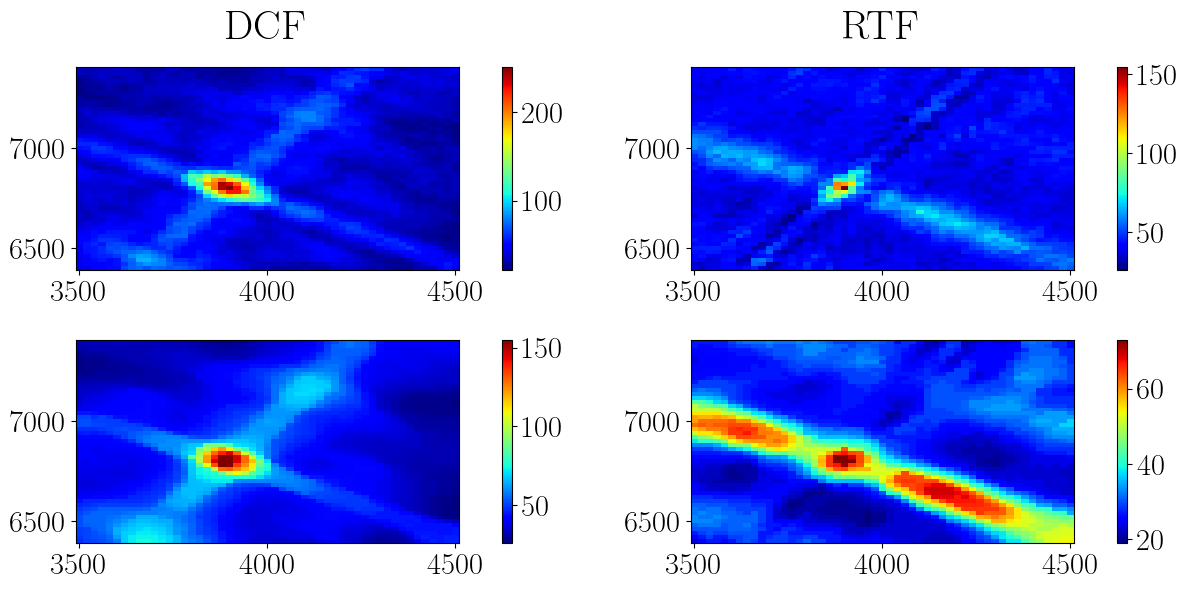

In [515]:
# Plot smoothed images
fig, axs = plt.subplots(2, 2, figsize=(12, 6))
im0 = axs[0, 0].pcolormesh(ds.x, ds.y, image_dcf, cmap="jet")
plt.colorbar(im0, ax=axs[0, 0])
im0 = axs[1, 0].pcolormesh(ds.x, ds.y, image_dcf_smooth, cmap="jet")
plt.colorbar(im0, ax=axs[1, 0])
axs[0, 0].set_title("DCF")

im1 = axs[0, 1].pcolormesh(ds.x, ds.y, image_rtf, cmap="jet")
plt.colorbar(im0, ax=axs[0, 1])
im1 = axs[1, 1].pcolormesh(ds.x, ds.y, image_rtf_smooth, cmap="jet")
axs[0, 1].set_title("RTF")
plt.colorbar(im1, ax=axs[1, 1])

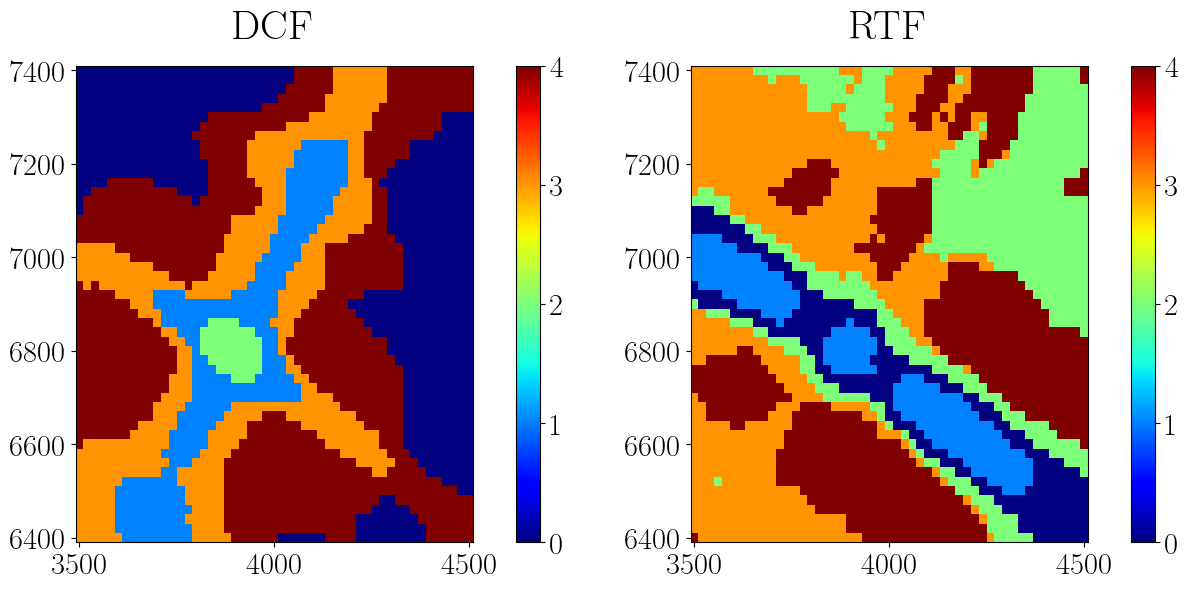

In [516]:
n_clusters = 5
# Extract coords
x_coord, y_coord = np.meshgrid(ds.x.values, ds.y.values)
# Kmeans avec intensités des pixels et coordonnées
X_dcf = np.vstack([x_coord.flatten(), y_coord.flatten(), image_dcf_smooth.flatten()])
X_rtf = np.vstack([x_coord.flatten(), y_coord.flatten(), image_rtf_smooth.flatten()])

labels_dcf = apply_kmeans(X_dcf, n_clusters)
labels_rtf = apply_kmeans(X_rtf, n_clusters)
# Reshape labels to 2d arrays
labels_dcf = labels_dcf.reshape(ds.d_gcc.shape)
labels_rtf = labels_rtf.reshape(ds.d_rtf.shape)
# Plot labels
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
im0 = axs[0].pcolormesh(ds.x, ds.y, labels_dcf, cmap="jet")
plt.colorbar(im0, ax=axs[0])
axs[0].set_title("DCF")
im1 = axs[1].pcolormesh(ds.x, ds.y, labels_rtf, cmap="jet")
axs[1].set_title("RTF")
plt.colorbar(im1, ax=axs[1])

## Masque associé

In [517]:
def get_src_pos_label(amb_surf, labels):
    x_idx, y_idx, _, _ = get_estimated_src_pos(amb_surf=amb_surf, loc_arg="max")
    ax_order = get_axis_order(da=amb_surf, ax_names=["x", "y"])
    idx_tuple = (y_idx, x_idx) if (ax_order["y"] == 0) else (x_idx, y_idx)
    src_hat_class = labels[idx_tuple]
    return src_hat_class

In [518]:
mask_dcf = labels_dcf == get_src_pos_label(amb_surf=ds.d_gcc, labels=labels_dcf)
mask_rtf = labels_rtf == get_src_pos_label(amb_surf=ds.d_rtf, labels=labels_rtf)

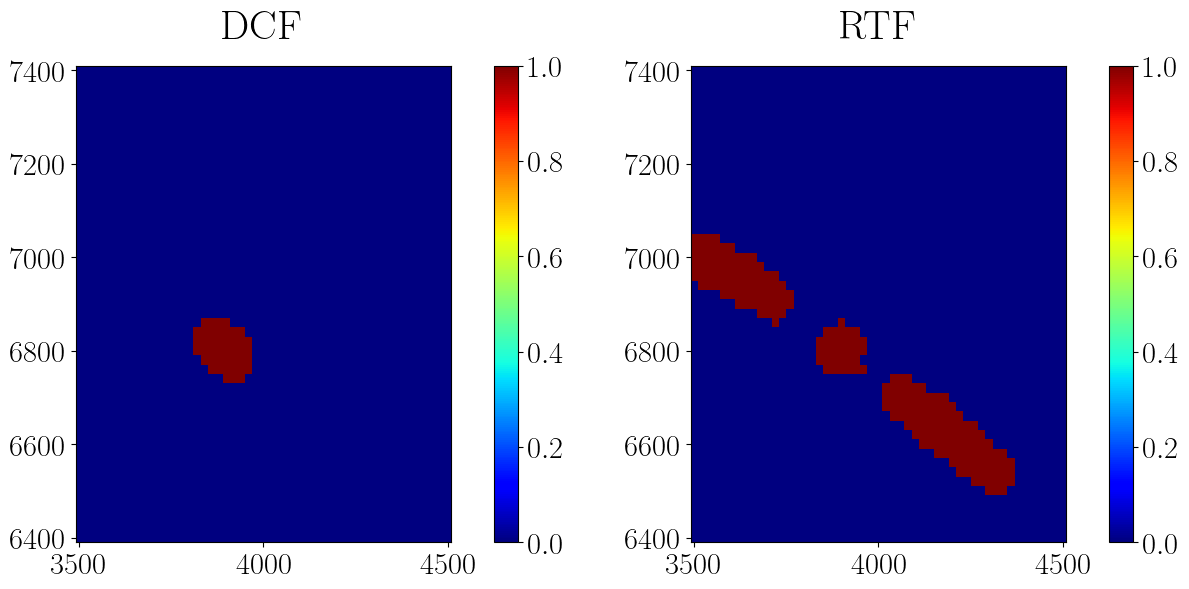

In [519]:
# Plot masks
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
im0 = axs[0].pcolormesh(ds.x, ds.y, mask_dcf, cmap="jet")
plt.colorbar(im0, ax=axs[0])
axs[0].set_title("DCF")

im1 = axs[1].pcolormesh(ds.x, ds.y, mask_rtf, cmap="jet")
axs[1].set_title("RTF")
plt.colorbar(im1, ax=axs[1])

In [520]:
# New labels to get the region of interest
mask_labeled_dcf, nlabel_dcf = label(mask_dcf)
mask_labeled_rtf, nlabel_dcf = label(mask_rtf)

In [521]:
mask_labeled_dcf

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

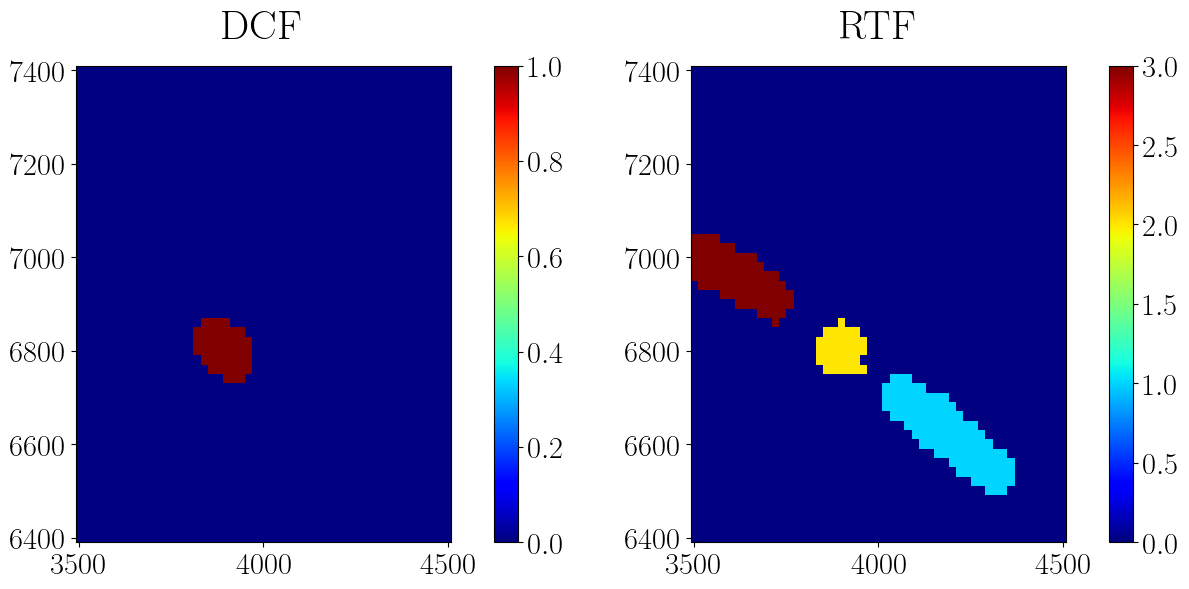

In [522]:
# Plot labeled masks
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
im0 = axs[0].pcolormesh(ds.x, ds.y, mask_labeled_dcf, cmap="jet")
plt.colorbar(im0, ax=axs[0])
axs[0].set_title("DCF")

im1 = axs[1].pcolormesh(ds.x, ds.y, mask_labeled_rtf, cmap="jet")
axs[1].set_title("RTF")
plt.colorbar(im1, ax=axs[1])

In [523]:
# Get labels of the region of interest
label_dcf = get_src_pos_label(amb_surf=ds.d_gcc, labels=mask_labeled_dcf)
label_rtf = get_src_pos_label(amb_surf=ds.d_rtf, labels=mask_labeled_rtf)

In [524]:
label_rtf

2

In [525]:
# Create new masks with only the region of interest
mask_dcf_new = mask_labeled_dcf == label_dcf
mask_rtf_new = mask_labeled_rtf == label_rtf

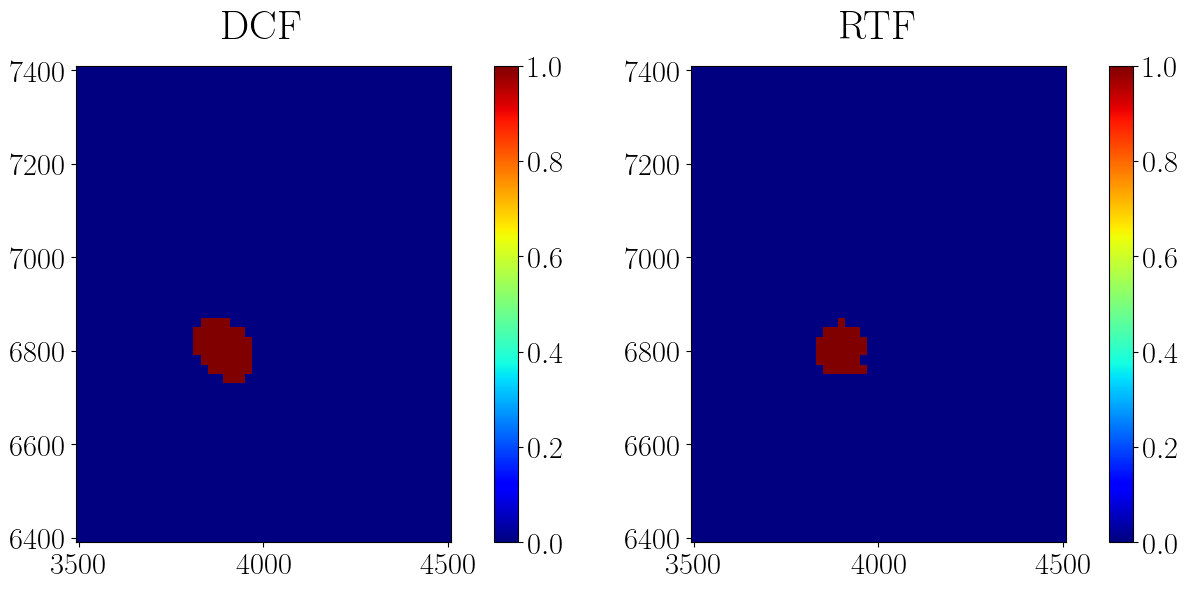

In [526]:
# Plot masks
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
im0 = axs[0].pcolormesh(ds.x, ds.y, mask_dcf_new, cmap="jet")
plt.colorbar(im0, ax=axs[0])
axs[0].set_title("DCF")

im1 = axs[1].pcolormesh(ds.x, ds.y, mask_rtf_new, cmap="jet")
axs[1].set_title("RTF")
plt.colorbar(im1, ax=axs[1])

### Post-traitement des masques pour s'assurer d'avoir pris tous les pixels et qu'il n'y ai pas de trous 

In [527]:
# Remove holes
mask_dcf_new = ndi.binary_fill_holes(mask_dcf_new)
mask_rtf_new = ndi.binary_fill_holes(mask_rtf_new)

In [528]:
# Expand regions
mask_dcf_new = binary_dilation(mask_dcf_new, iterations=2)
mask_rtf_new = binary_dilation(mask_rtf_new, iterations=2)

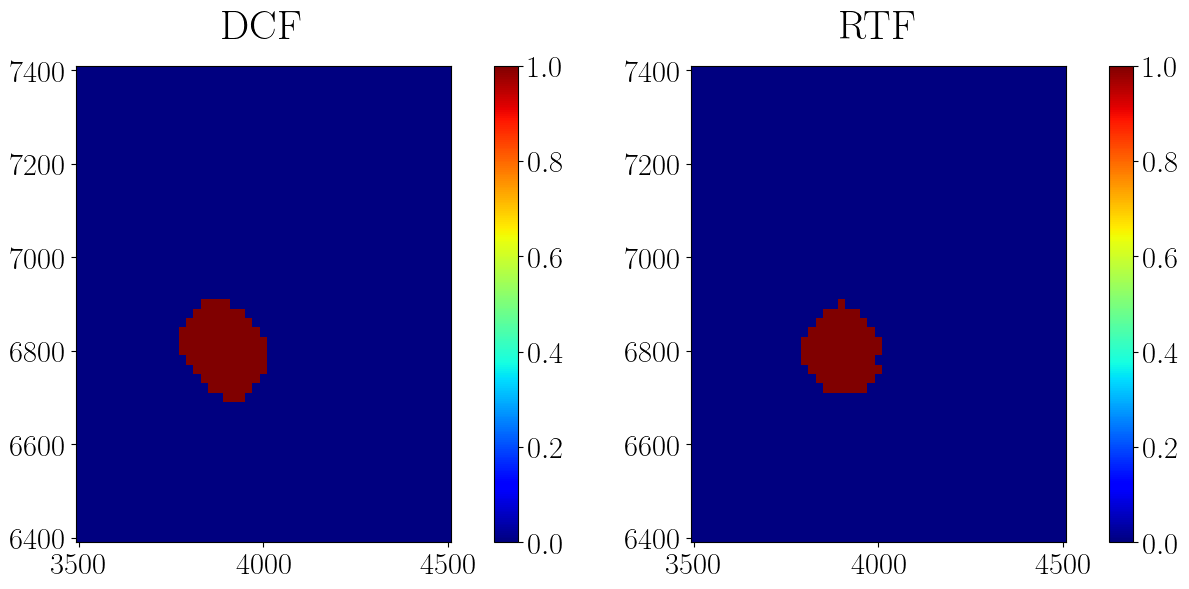

In [529]:
# Plot expanded masks
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
im0 = axs[0].pcolormesh(ds.x, ds.y, mask_dcf_new, cmap="jet")
plt.colorbar(im0, ax=axs[0])
axs[0].set_title("DCF")

im1 = axs[1].pcolormesh(ds.x, ds.y, mask_rtf_new, cmap="jet")
axs[1].set_title("RTF")
plt.colorbar(im1, ax=axs[1])

In [530]:
def main_lobe_contours(amb_surf, mask):
    x_idx, y_idx, _, _ = get_estimated_src_pos(amb_surf=amb_surf, loc_arg="max")
    ax_order = get_axis_order(da=amb_surf, ax_names=["x", "y"])

    # Find contours of src_hat_class and select the contour corresponding to the estimated position
    contours = measure.find_contours(mask, level=0.5)
    for contour in contours:
        # Check if src_hat is within the contour
        idx_x_min = np.min(contour[:, ax_order["x"]].astype(int))
        idx_x_max = np.max(contour[:, ax_order["x"]].astype(int))
        idx_y_min = np.min(contour[:, ax_order["y"]].astype(int))
        idx_y_max = np.max(contour[:, ax_order["y"]].astype(int))
        if (idx_x_min <= x_idx <= idx_x_max) and (idx_y_min <= y_idx <= idx_y_max):
            break

    return contour

In [531]:
ax_order = get_axis_order(da=ds.d_gcc, ax_names=["x", "y"])
contour_dcf = main_lobe_contours(amb_surf=ds.d_gcc, mask=mask_dcf_new)
contour_rtf = main_lobe_contours(amb_surf=ds.d_rtf, mask=mask_rtf_new)

In [532]:
contour_dcf.shape

(47, 2)

Text(0.5, 1.0, 'Smooth RTF')

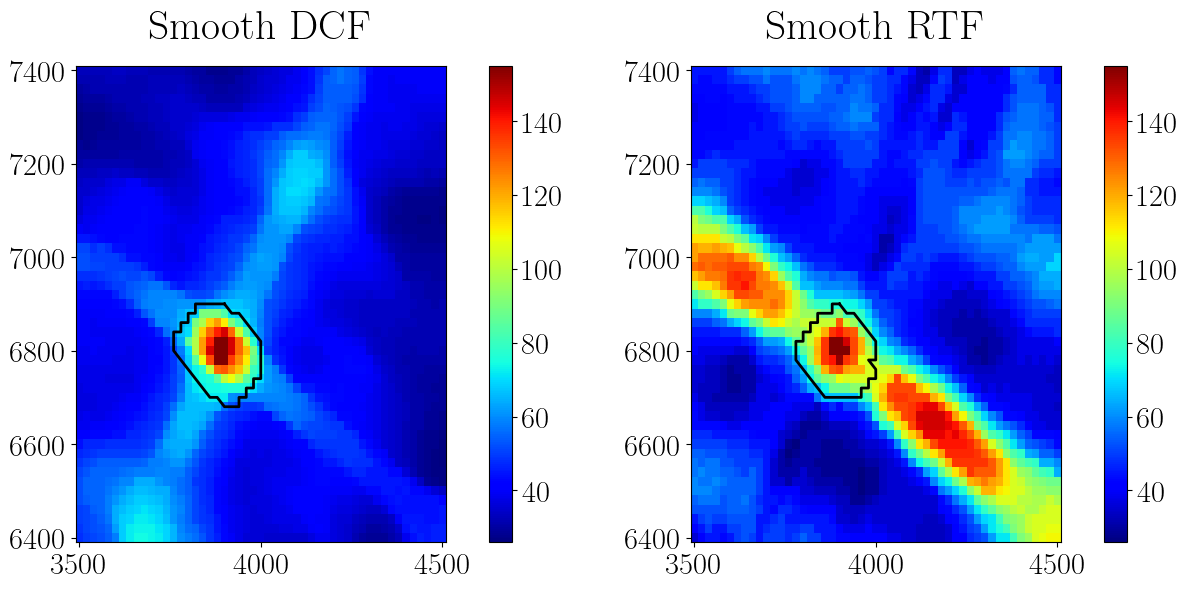

In [533]:
# Plot original image and contour
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
im0 = axs[0].pcolormesh(ds.x, ds.y, image_dcf_smooth, cmap="jet")
plt.colorbar(im0, ax=axs[0])
axs[0].plot(
    ds["x"].values[contour_dcf[:, ax_order["x"]].astype(int)],
    ds["y"].values[contour_dcf[:, ax_order["y"]].astype(int)],
    color="k",
    linewidth=2,
    label="Contour",
)
axs[0].set_title(" Smooth DCF")

im1 = axs[1].pcolormesh(ds.x, ds.y, image_rtf_smooth, cmap="jet")
plt.colorbar(im0, ax=axs[1])
axs[1].plot(
    ds["x"].values[contour_rtf[:, ax_order["x"]].astype(int)],
    ds["y"].values[contour_rtf[:, ax_order["y"]].astype(int)],
    color="k",
    linewidth=2,
    label="Contour",
)
axs[1].set_title("Smooth RTF")

Text(0.5, 1.0, 'RTF')

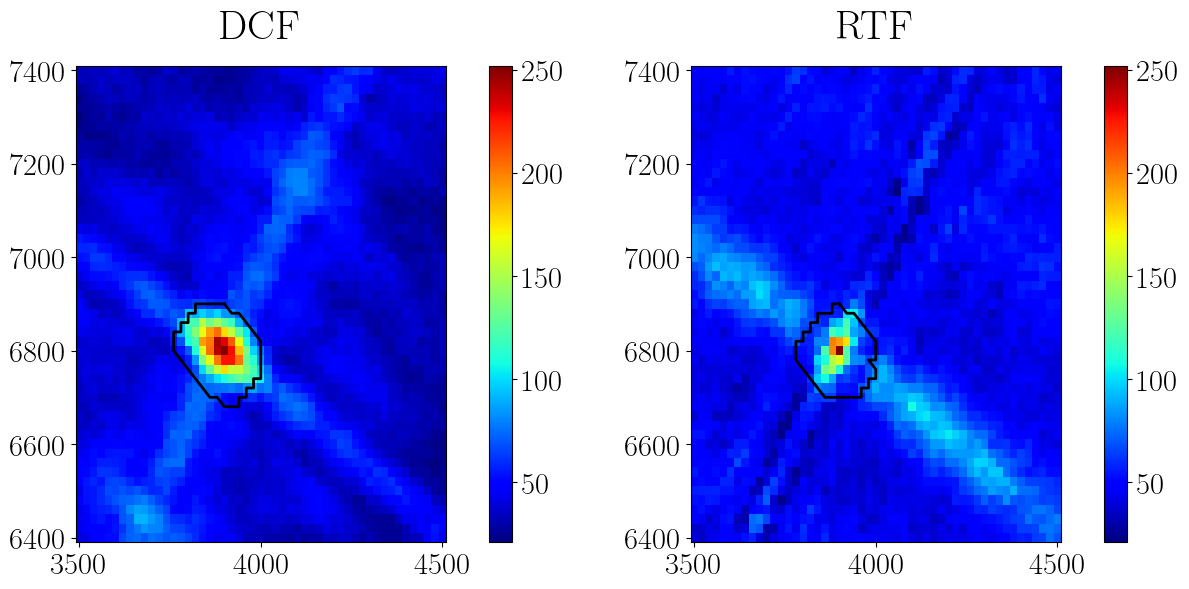

In [534]:
# Plot contour on original image
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
im0 = axs[0].pcolormesh(ds.x, ds.y, image_dcf, cmap="jet")
plt.colorbar(im0, ax=axs[0])
axs[0].plot(
    ds["x"].values[contour_dcf[:, ax_order["x"]].astype(int)],
    ds["y"].values[contour_dcf[:, ax_order["y"]].astype(int)],
    color="k",
    linewidth=2,
    label="Contour",
)
axs[0].set_title("DCF")

im1 = axs[1].pcolormesh(ds.x, ds.y, image_rtf, cmap="jet")
plt.colorbar(im0, ax=axs[1])
axs[1].plot(
    ds["x"].values[contour_rtf[:, ax_order["x"]].astype(int)],
    ds["y"].values[contour_rtf[:, ax_order["y"]].astype(int)],
    color="k",
    linewidth=2,
    label="Contour",
)
axs[1].set_title("RTF")

# Label from scikit.measure

In [535]:
labels_dcf_new, n_features_dcf = label(labels_dcf)
labels_rtf_new, n_features_rtf = label(labels_rtf)

In [536]:
labels_dcf_new.shape

(51, 51)

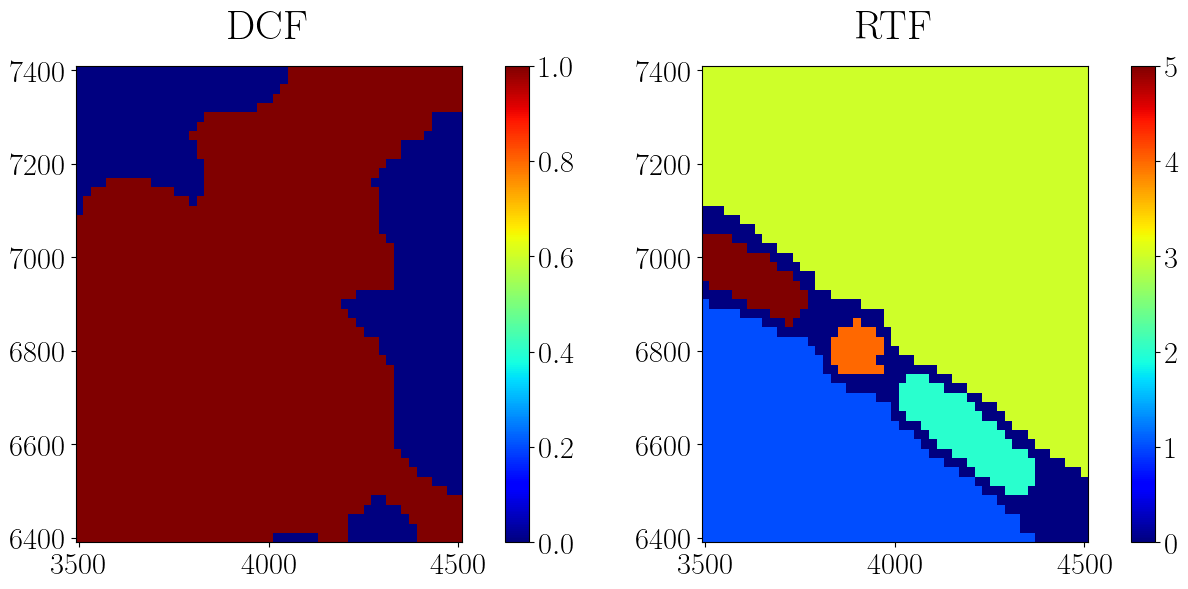

In [537]:
# Plot new labels
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
im0 = axs[0].pcolormesh(ds.x, ds.y, labels_dcf_new, cmap="jet")
plt.colorbar(im0, ax=axs[0])
axs[0].set_title("DCF")

im1 = axs[1].pcolormesh(ds.x, ds.y, labels_rtf_new, cmap="jet")
axs[1].set_title("RTF")
plt.colorbar(im1, ax=axs[1])

## Watershed (Scikit-image)

In [538]:
disk_size = 2
image_dcf_smooth = rank.median(image_dcf, disk(disk_size))
image_rtf_smooth = rank.median(image_rtf, disk(disk_size))

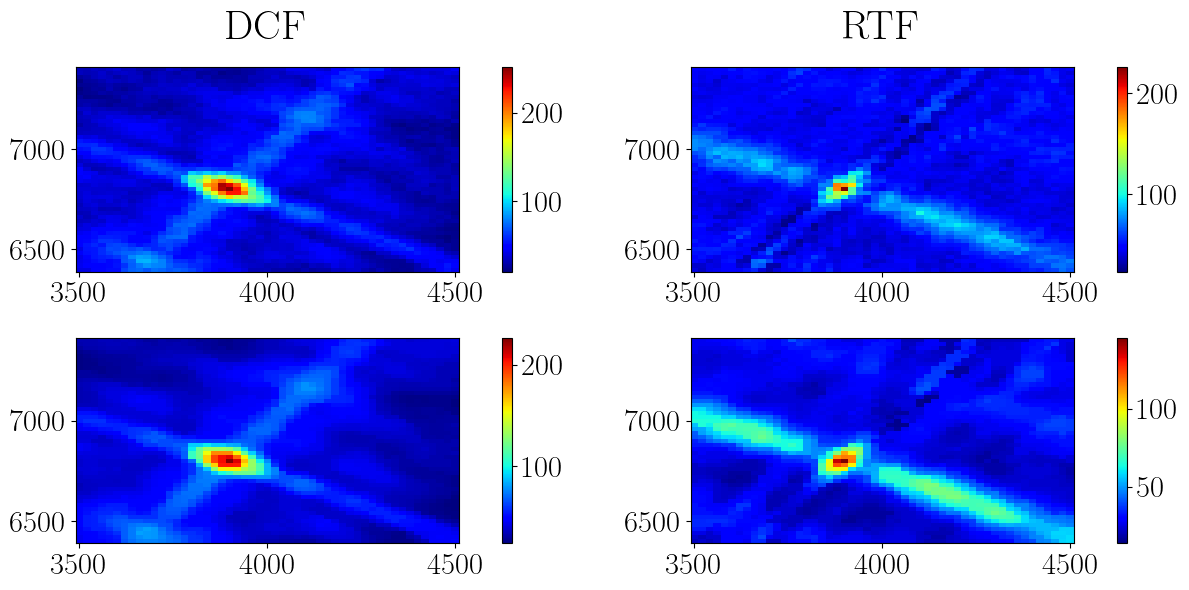

In [539]:
# Plot smoothed images
fig, axs = plt.subplots(2, 2, figsize=(12, 6))
im0 = axs[0, 0].pcolormesh(ds.x, ds.y, image_dcf, cmap="jet")
plt.colorbar(im0, ax=axs[0, 0])
im0 = axs[1, 0].pcolormesh(ds.x, ds.y, image_dcf_smooth, cmap="jet")
plt.colorbar(im0, ax=axs[1, 0])
axs[0, 0].set_title("DCF")

im1 = axs[0, 1].pcolormesh(ds.x, ds.y, image_rtf, cmap="jet")
plt.colorbar(im0, ax=axs[0, 1])
im1 = axs[1, 1].pcolormesh(ds.x, ds.y, image_rtf_smooth, cmap="jet")
axs[0, 1].set_title("RTF")
plt.colorbar(im1, ax=axs[1, 1])

In [540]:
grad_dcf = rank.gradient(image_dcf_smooth, disk(5))
grad_rtf = rank.gradient(image_rtf_smooth, disk(5))

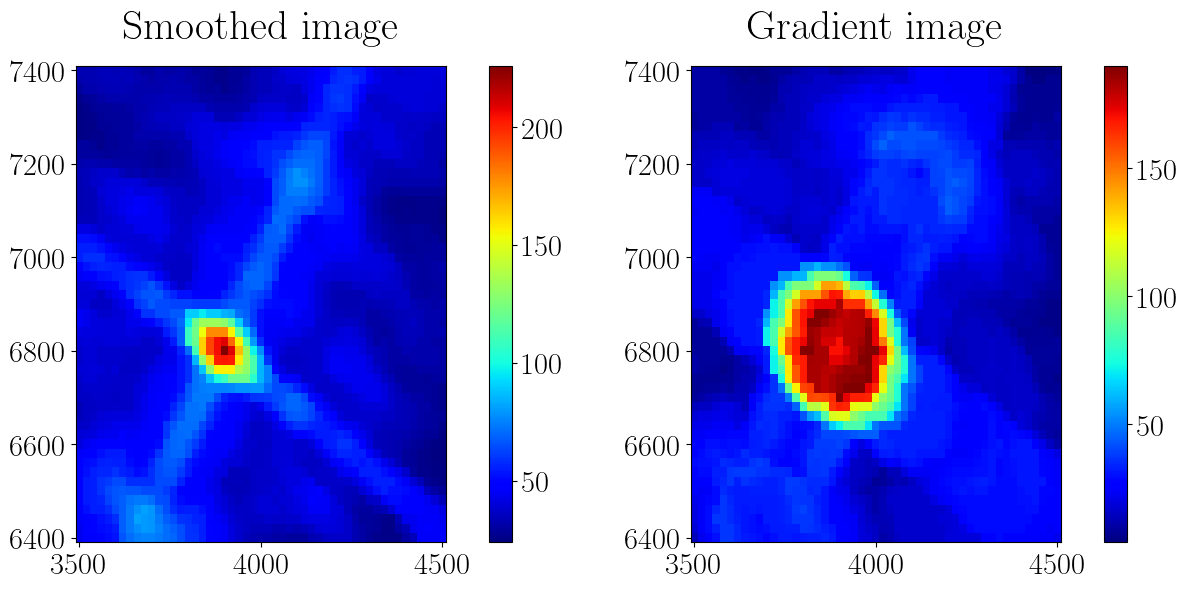

In [541]:
# Plot gradient
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
im0 = axs[0].pcolormesh(ds.x, ds.y, image_dcf_smooth, cmap="jet")
axs[0].set_title("Smoothed image")
plt.colorbar(im0, ax=axs[0])
im = axs[1].pcolormesh(ds.x, ds.y, grad_dcf, cmap="jet")
axs[1].set_title("Gradient image")
plt.colorbar(im, ax=axs[1])

In [542]:
# find continuous region (low gradient -
# where less than 10 for this image) --> markers
# disk(5) is used here to get a more smooth image
markers = grad_dcf < 5
markers = ndi.label(markers)[0]

In [543]:
markers.shape

(51, 51)

In [544]:
# local gradient (disk(2) is used to keep edges thin)
gradient = rank.gradient(image_dcf_smooth, disk(2))

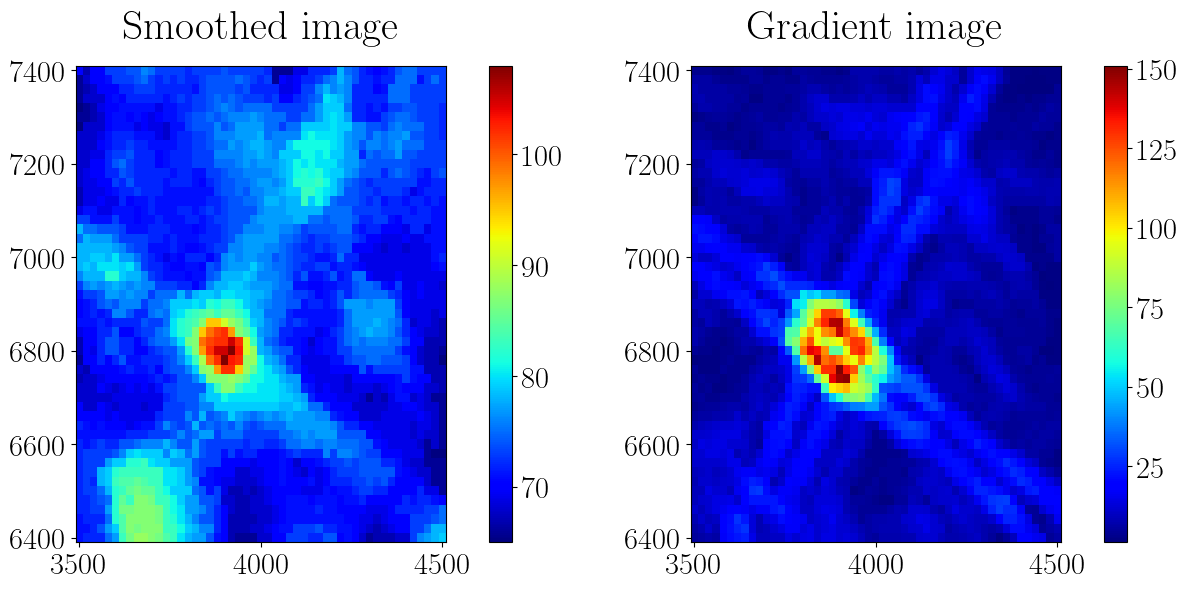

In [545]:
# Plot gradient
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
im0 = axs[0].pcolormesh(ds.x, ds.y, denoised, cmap="jet")
axs[0].set_title("Smoothed image")
plt.colorbar(im0, ax=axs[0])
im = axs[1].pcolormesh(ds.x, ds.y, gradient, cmap="jet")
axs[1].set_title("Gradient image")
plt.colorbar(im, ax=axs[1])

In [546]:
# process the watershed
labels = watershed(gradient, 10)

Text(0.5, 0.98, 'DCF')

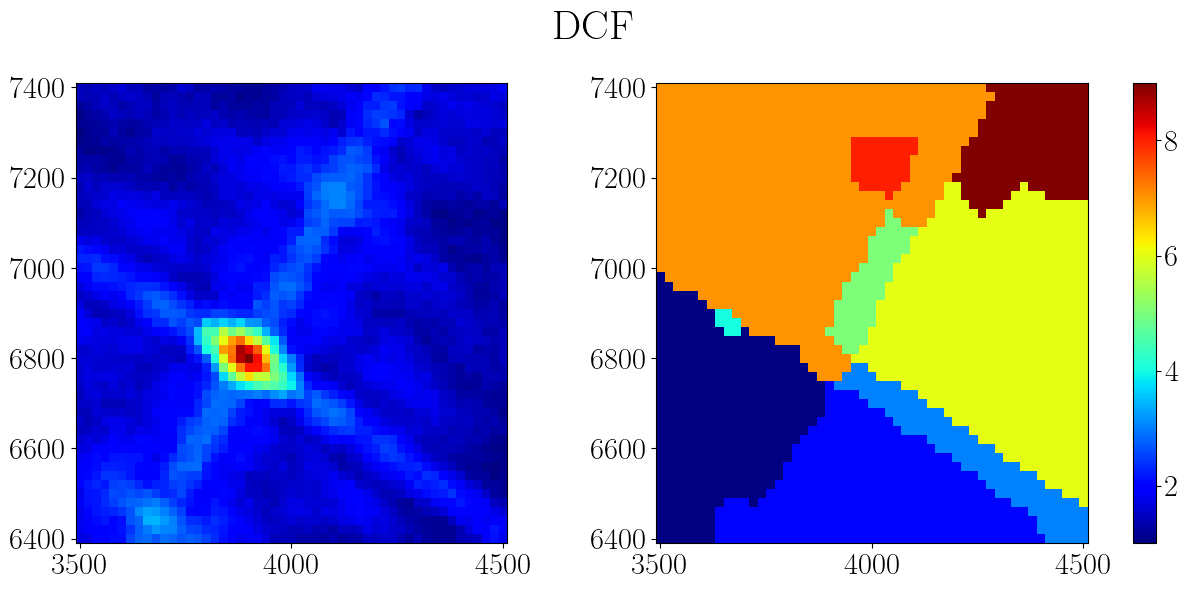

In [547]:
# Plot results
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
im0 = axs[0].pcolormesh(ds.x, ds.y, image_dcf, cmap="jet")
im = axs[1].pcolormesh(ds.x, ds.y, labels, cmap="jet")
plt.colorbar(im, ax=axs[1])
plt.suptitle("DCF")


In [548]:
image.max()

192